In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import math

In [15]:
#https://www.openml.org/search?type=data&sort=runs&id=40498&status=active
# white-wine-quality

dataset = openml.datasets.get_dataset(40498)

X, y, _, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

# Połączenie cech i etykiety w jeden DataFrame (opcjonalnie)
d = pd.concat([X, y], axis=1)

print(d.head())
print(len(d))
d = d.dropna()
print(len(d))

    V1    V2    V3    V4     V5    V6     V7      V8    V9   V10   V11 Class
0  7.0  0.27  0.36  20.7  0.045  45.0  170.0  1.0010  3.00  0.45   8.8     4
1  6.3  0.30  0.34   1.6  0.049  14.0  132.0  0.9940  3.30  0.49   9.5     4
2  8.1  0.28  0.40   6.9  0.050  30.0   97.0  0.9951  3.26  0.44  10.1     4
3  7.2  0.23  0.32   8.5  0.058  47.0  186.0  0.9956  3.19  0.40   9.9     4
4  7.2  0.23  0.32   8.5  0.058  47.0  186.0  0.9956  3.19  0.40   9.9     4
4898
4898


V1       float64
V2       float64
V3       float64
V4       float64
V5       float64
V6       float64
V7       float64
V8       float64
V9       float64
V10      float64
V11      float64
Class      int64
dtype: object


<Axes: >

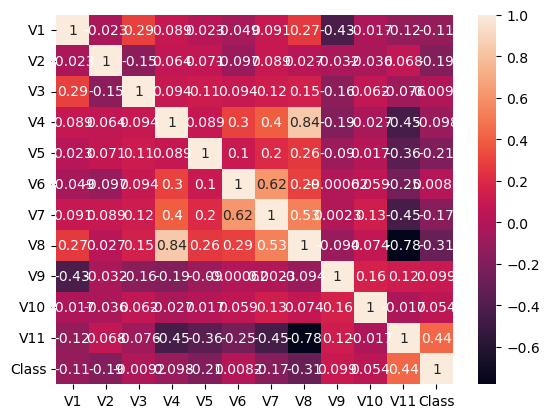

In [37]:
data = pd.DataFrame(d)
data["Class"] = data["Class"].astype(int)
print(data.dtypes)
sns.heatmap(data.corr(), annot=True)

In [99]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn import svm

import optuna
from optuna.samplers import TPESampler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from scipy.stats import wilcoxon

In [54]:
X_train, X_test, Y_train, Y_test = train_test_split(data.iloc[:,:11], data.loc[:,"Class"], test_size=0.2, shuffle=True, random_state=42)
cv = KFold(n_splits = 5, shuffle=True, random_state=42)

n_feat_total = X_train.shape[1]

In [90]:
def objective(trial):
    # hiperparametry potrzebne w zadaniu
    
    n_features = trial.suggest_int("n_features", 5, n_feat_total)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),     # okresla liczbe drzew, ile kolejnych drzew budujemy
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split",2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf",1, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0)      # frakcja probek uzywana do trenowania kazdego drzewa, czyli jesli sumbsample = 0.6
        # to drzewo widzi 0.6 danych treningowych, w konsekwencji mamy bardziej stabilny model
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kbest', SelectKBest(score_func=f_regression, k=n_features)),
        ('model', GradientBoostingRegressor(**params))
    ])

    scores = cross_val_score(pipeline, X_train, Y_train, cv = cv, scoring = "r2")

    return scores.mean()

In [101]:
study = optuna.create_study(
    direction="maximize", 
    sampler = TPESampler(seed=42) # to mowi nam o tym jakie kombinacje hiperparametrow wybrac w kolejnych trialach
    # direction szuka najlepszego mozliwego wyniku, a sampler mowi zeby szukac za pomoca jakis wzorcow
)
all_trial_scores = []

def objective_wrapper(trial):
    scores = objective(trial)
    all_trial_scores.append(scores)
    return np.mean(scores)


study.optimize(objective_wrapper, n_trials=30)


print("Best Val: ", study.best_value)
print("Best params: ", study.best_params)

[I 2025-11-29 13:11:22,685] A new study created in memory with name: no-name-f68b914f-65f4-4a08-9333-c39631f1bdd9
[I 2025-11-29 13:11:51,822] Trial 0 finished with value: 0.41022911121251926 and parameters: {'n_features': 7, 'n_estimators': 288, 'max_depth': 16, 'min_samples_split': 13, 'min_samples_leaf': 2, 'learning_rate': 0.055238410897498764, 'subsample': 0.6232334448672797}. Best is trial 0 with value: 0.41022911121251926.
[I 2025-11-29 13:12:27,095] Trial 1 finished with value: 0.41406431972810437 and parameters: {'n_features': 11, 'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 10, 'learning_rate': 0.2514083658321223, 'subsample': 0.6849356442713105}. Best is trial 1 with value: 0.41406431972810437.
[I 2025-11-29 13:12:35,229] Trial 2 finished with value: 0.39250989154445454 and parameters: {'n_features': 6, 'n_estimators': 96, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 5, 'learning_rate': 0.09445645065743215, 'subsample': 0.8

Best Val:  0.47508223155156737
Best params:  {'n_features': 11, 'n_estimators': 152, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 8, 'learning_rate': 0.09947430722234461, 'subsample': 0.7503495285927133}


In [116]:
KNeighborsRegressor().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [134]:
best_n_features = study.best_params["n_features"]
best_params = {k: v for k, v in study.best_params.items() if k != "n_features"}

rf_param_list = [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
]

rf_params = {k: v for k, v in best_params.items() if k in rf_param_list}

kn_param_list = [
    'algorithm',
     'leaf_size',
     'metric',
     'metric_params',
     'n_jobs',
     'n_neighbors',
     'p',
     'weights',
]

kn_params = {k: v for k, v in best_params.items() if k in kn_param_list}

print(rf_params)

# random_forest regressor
def make_final_prediction(model):
    if model == RandomForestRegressor:
        best_model = Pipeline([
            ("scaler", StandardScaler()),
            ("kbest", SelectKBest(score_func=f_regression, k=best_n_features)),
            ("model", model(**rf_params))
        ])
    elif model == KNeighborsRegressor:
        best_model = Pipeline([
            ("scaler", StandardScaler()),
            ("kbest", SelectKBest(score_func=f_regression, k=best_n_features)),
            ("model", model(**kn_params))
        ])
    
    
    best_model.fit(X_train, Y_train)
    res = best_model.predict(X_test)
    r2 = r2_score(Y_test, res)
    mse = mean_squared_error(Y_test, res)

    print("Final results for", model , ": ")
    print("R2: ", r2)
    print("MSE: ", mse)

    return res, r2, mse
random_res, random_r2, random_mse  = make_final_prediction(RandomForestRegressor)
knn_res, knn_r2, knn_mse = make_final_prediction(KNeighborsRegressor) # nie ma sensu, bo parametry z optuny dla Gradient Boostingu nie pasuja dla KNR, trzeba by zrobic osobna optune dla KNR

{}
Final results for <class 'sklearn.ensemble._forest.RandomForestRegressor'> : 
R2:  0.5507195847293104
MSE:  0.34795561224489796
Final results for <class 'sklearn.neighbors._regression.KNeighborsRegressor'> : 
R2:  0.3825295373512376
MSE:  0.47821428571428576


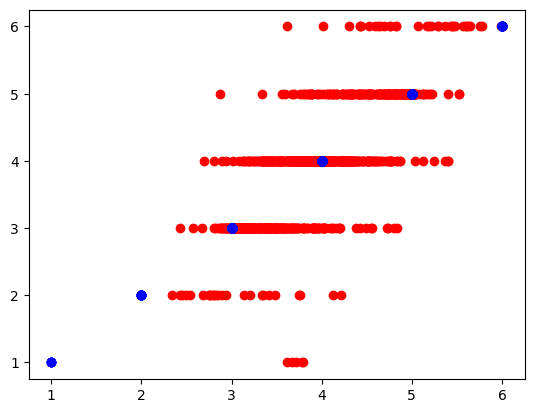

In [139]:
plt.scatter(random_res, Y_test, color="r")
plt.scatter(Y_test, Y_test, color="b")

0.21843325214111753
-0.6895569804157062


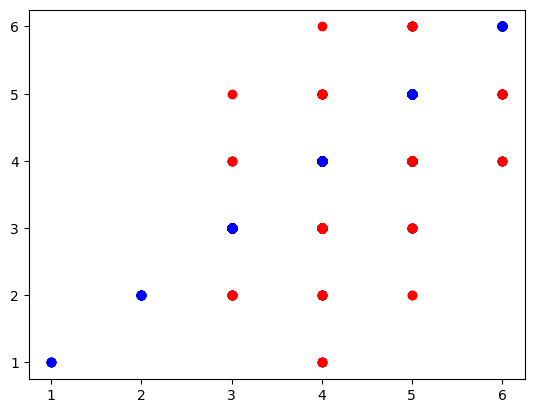

In [152]:
random_res_rounded1 = np.ceil(random_res).astype(int)
random_res_rounded2 = np.round(random_res)
print(r2_score(random_res_rounded2, Y_test))
print(r2_score(random_res_rounded1, Y_test))
plt.scatter(random_res_rounded1, Y_test, color="r")
plt.scatter(Y_test, Y_test, color="b")

{'whiskers': [<matplotlib.lines.Line2D at 0x192427bb750>,
 'caps': [<matplotlib.lines.Line2D at 0x192427bb9d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x192427bb610>,
 'medians': [<matplotlib.lines.Line2D at 0x192427bbc50>,
 'fliers': [<matplotlib.lines.Line2D at 0x192427bbd90>,
 'means': []}

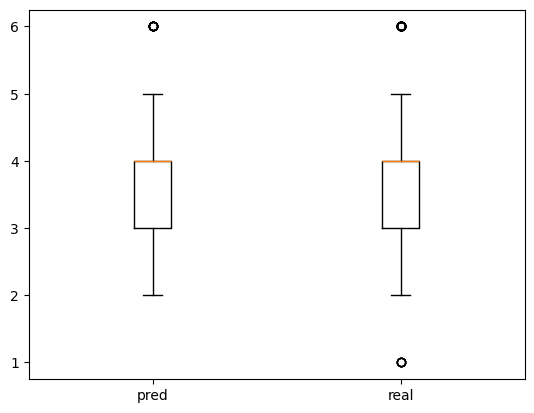

In [144]:
plt.boxplot([random_res_rounded, Y_test], tick_labels=["pred", "real"])

In [ ]:
best_idx = study.best_trial.number
best_cv = all_trial_scores[best_idx]

mean_scores = [np.mean(s) for s in all_trial_scores]
second_idx = np.argsort(mean_scores)[-2]
second_cv = all_trial_scores[second_idx]

print("CV najlepszego triala:", best_cv)
print("CV drugiego triala:", second_cv)


stat, p = wilcoxon(best_cv, second_cv)

print("Statystyka Wilcoxona:", stat)
print("p-value:", p)

In [129]:
def objective(trial):
    # hiperparametry potrzebne w zadaniu
    
    n_features = trial.suggest_int("n_features", 5, n_feat_total)

    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 5, 10),
        "weights": "distance",
        "p": trial.suggest_int("p",2, 10),
        "leaf_size": trial.suggest_int("leaf_size",30, 40)
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kbest', SelectKBest(score_func=f_regression, k=n_features)),
        ('model', KNeighborsRegressor(**params))
    ])

    scores = cross_val_score(pipeline, X_train, Y_train, cv = cv, scoring = "r2")

    return scores.mean()




study = optuna.create_study(
    direction="maximize", 
    sampler = TPESampler(seed=42) # to mowi nam o tym jakie kombinacje hiperparametrow wybrac w kolejnych trialach
    # direction szuka najlepszego mozliwego wyniku, a sampler mowi zeby szukac za pomoca jakis wzorcow
)
all_trial_scores = []

def objective_wrapper(trial):
    scores = objective(trial)
    all_trial_scores.append(scores)
    return np.mean(scores)


study.optimize(objective_wrapper, n_trials=30)

[I 2025-11-29 19:04:41,916] A new study created in memory with name: no-name-3afbe3b1-1a8b-4215-98ba-bd5a4e6dc197
[I 2025-11-29 19:04:42,582] Trial 0 finished with value: 0.4434992260595799 and parameters: {'n_features': 7, 'n_neighbors': 10, 'p': 8, 'leaf_size': 36}. Best is trial 0 with value: 0.4434992260595799.
[I 2025-11-29 19:04:42,793] Trial 1 finished with value: 0.3979643220346518 and parameters: {'n_features': 6, 'n_neighbors': 5, 'p': 2, 'leaf_size': 39}. Best is trial 0 with value: 0.4434992260595799.
[I 2025-11-29 19:04:43,043] Trial 2 finished with value: 0.4516601133155723 and parameters: {'n_features': 9, 'n_neighbors': 9, 'p': 2, 'leaf_size': 40}. Best is trial 2 with value: 0.4516601133155723.
[I 2025-11-29 19:04:44,649] Trial 3 finished with value: 0.45594268186464604 and parameters: {'n_features': 10, 'n_neighbors': 6, 'p': 3, 'leaf_size': 32}. Best is trial 3 with value: 0.45594268186464604.
[I 2025-11-29 19:04:45,409] Trial 4 finished with value: 0.432833653532959

In [130]:
print("Best Val: ", study.best_value)
print("Best params: ", study.best_params)

best_knn_features = study.best_params["n_features"]

knn_best_params = {k: v for k, v in study.best_params.items() if k != "n_features"}


final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(score_func=f_regression, k=best_knn_features)),
    ("model", KNeighborsRegressor(**knn_best_params))
])


final_knn.fit(X_train, Y_train)
res = final_knn.predict(X_test)


print("Final results for KNN: ")
print("R2: ", r2_score(res, Y_test))
print("MSE: ", mean_squared_error(res, Y_test))

Best Val:  0.47160304395378805
Best params:  {'n_features': 11, 'n_neighbors': 10, 'p': 2, 'leaf_size': 37}
Final results for KNN: 
R2:  -0.41500276899069344
MSE:  0.47821428571428576


In [131]:
best_idx = study.best_trial.number
best_cv = all_trial_scores[best_idx]

mean_scores = [np.mean(s) for s in all_trial_scores]
second_idx = np.argsort(mean_scores)[-2]
second_cv = all_trial_scores[second_idx]

print("CV najlepszego triala:", best_cv)
print("CV drugiego triala:", second_cv)


stat, p = wilcoxon(best_cv, second_cv)

print("Statystyka Wilcoxona:", stat)
print("p-value:", p)

CV najlepszego triala: 0.47160304395378805
CV drugiego triala: 0.47160304395378805


C:\Users\Pytla\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


ValueError: each sample in `data` must contain two or more observations along `axis`.